In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



def fdtd_error(Ey_num, Hz_num, Ey_exact, Hz_exact):
    """
    Computes a combined relative L2 error for Ey and Hz over space and time.

    Parameters:
        Ey_num, Hz_num   : numerical solutions (Nt x Nx)
        Ey_exact, Hz_exact : analytical solutions (Nt x Nx)

    Returns:
        total_error : scalar (relative L2 error)
        Ey_error    : scalar (relative L2 error for Ey)
        Hz_error    : scalar (relative L2 error for Hz)
    """

    # --- Ey error ---
    err_Ey = Ey_num - Ey_exact
    norm_Ey = np.sqrt(np.mean(err_Ey**2))
    ref_Ey  = np.sqrt(np.mean(Ey_exact**2))
    Ey_error = norm_Ey / ref_Ey

    # --- Hz error ---
    err_Hz = Hz_num - Hz_exact
    norm_Hz = np.sqrt(np.mean(err_Hz**2))
    ref_Hz  = np.sqrt(np.mean(Hz_exact**2))
    Hz_error = norm_Hz / ref_Hz

    # --- combined error ---
    total_error = np.sqrt(norm_Ey**2 + norm_Hz**2) / np.sqrt(ref_Ey**2 + ref_Hz**2)

    return total_error, Ey_error, Hz_error

# Parameters
e0 = 1 
mu0 = 1 
vp = 1 / np.sqrt(e0 * mu0)

a = 1 # tamanho da reta (eixo x)
T = 1 # tempo de simulação 

dx_list = [0.04, 0.02, 0.01, 0.005]

rel_err_list = []
error_ey_list = []

for dx in dx_list:
    dt = dx / 2

    nx = int(a / dx)
    nt = int(T / dt)

    xgrid = np.linspace(0, a, nx) # xgrid para o Ey
    tgrid = np.linspace(0, T, nt) # tgrid para o Ey

    xgrid_interc = np.linspace(dx / 2, a - dx / 2, nx - 1) # xgrid para o Hz
    tgrid_interc = np.linspace(dt / 2, T - dt / 2, nt - 1) # tgrid para o Hz

    # campos
    Ey = np.zeros((nt, nx))
    Hz = np.zeros((nt-1, nx-1))

    # valor inicial do campo Ey em t = 0
    Ey[0, :] = np.sin(np.pi / a * xgrid)

    # marcha no tempo
    for n in range(nt - 2):
        # atualiza o H
        Hz[n+1, :] = Hz[n, :] - (dt / (mu0 * dx)) * (Ey[n, 1:] - Ey[n, :-1])

        # atualiza o E
        Ey[n+1, 1:-1] = Ey[n, 1:-1] -(dt / (e0 * dx)) * (Hz[n+1, 1:] - Hz[n+1, :-1])

        # zero na condição de contorno (extremidades)
        Ey[n+1, 0] = 0
        Ey[n+1, -1] = 0

    # preenche com a solução exata
    # campos
    Ey_exact = np.zeros((nt, nx))
    Hz_exact = np.zeros((nt, nx-1))

    for n in range(nt):
        for i in range(nx):
            curr_t_ey = tgrid[n]
            curr_x_ey = xgrid[i]

            Ey_exact[n, i] = np.cos(vp * np.pi / a * curr_t_ey) * np.sin(np.pi / a * curr_x_ey)
            if i < nx - 1 and n < nt - 1:
                curr_x_hz = xgrid_interc[i]
                curr_t_hz = tgrid_interc[n]
                Hz_exact[n, i] = -1 * np.sin(vp * np.pi / a * curr_t_hz) * np.cos(np.pi / a * curr_x_hz)

    # solucao exata e numericas calculas. define as metricas de erro
    
    # calcula a energia em cada um em cada instante de tempo
    energy_analytical_by_t = []
    energy_num_by_t = []

    for n in range(nt - 1):
        # analitica
        y_fun = Ey_exact[n, :-1]**2 + Hz_exact[n, :]**2
        x_fun = xgrid[:-1]
        integral = np.trapezoid(y_fun, x_fun)
        energy_analytical_by_t.append(np.sqrt(integral))

        # numerica
        y_fun = Ey[n, :-1]**2 + Hz[n, :]**2
        x_fun = xgrid[:-1]
        integral = np.trapezoid(y_fun, x_fun)
        energy_num_by_t.append(np.sqrt(integral))

    # em cada instante de tempo, toma a diferença
    diff_energy_by_t = []
    for n in range(nt - 1):
        diff_energy_by_t.append(np.sqrt((energy_analytical_by_t[n] - energy_num_by_t[n])**2))

    # calcula o erro relativo
    rel_err = np.array(diff_energy_by_t) / np.array(energy_analytical_by_t)

    # rel_err_list.append(rel_err)


    def norm(N, arr):
        sum = 0
        for k in range(N):
            sum += arr[k]**2
        return np.sqrt(dx * sum)
    
    rel_err = []
    for n in range (nt - 1):
        numerator = np.sqrt(norm(nx, Ey_exact[n, :] - Ey[n, :])**2 + norm(nx-1, Hz_exact[n, :] - Hz[n, :])**2)
        denominator = energy_analytical_by_t[n]

        rel_err.append(numerator / denominator)

    rel_err_list.append(rel_err)


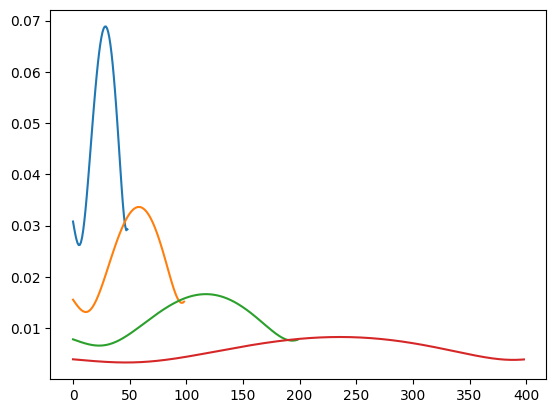

In [48]:
for i, dx in enumerate(dx_list):
    plt.plot(rel_err_list[i])